In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, accuracy_score

# 1. Load the dataset
path ="/content/drive/MyDrive/archive/Data/go_emotions_dataset.csv"
df = pd.read_csv(path)

# 2. Select the text and the emotion columns
text_data = df['text']
emotions = df.columns[3:]  # admiration, amusement, etc.
labels = df[emotions].values

# 3. For learning purposes, let's take a sample of 20,000 rows to make it run faster
df_sample = df.sample(20000, random_state=42)
X = df_sample['text']
y = df_sample[emotions].values

# 4. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- NEW ADDITION BELOW ---
print("--- Here are the first 6 rows of your dataset ---")
# df.head(6) tells pandas to show the top 6 rows.
# display() is a Colab-specific function that makes the table look pretty.
display(df.head(6))
# --------------------------

print(f"\nData ready! Training on {len(X_train)} samples, testing on {len(X_test)} samples.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Here are the first 6 rows of your dataset ---


,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,eespn2i,Right? Considering it’s such an important docu...,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Data ready! Training on 16000 samples, testing on 4000 samples.


In [ ]:
from sklearn.metrics import f1_score, accuracy_score

# 1. Convert text to numbers (Vectorization)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 2. Basic Model: Logistic Regression wrapped for multi-label
# OneVsRest means we train one mini-model for every single emotion
basic_model = OneVsRestClassifier(LogisticRegression(solver='liblinear'))
basic_model.fit(X_train_tfidf, y_train)

# 3. Predict and evaluate
y_pred_basic = basic_model.predict(X_test_tfidf)

# Calculate metrics
basic_f1 = f1_score(y_test, y_pred_basic, average='micro')
basic_accuracy = accuracy_score(y_test, y_pred_basic)

# Print results
print(f"Basic Model (Logistic Regression) F1 Score: {basic_f1:.4f}")
print(f"Basic Model (Logistic Regression) Accuracy: {basic_accuracy:.4f}")

Basic Model (Logistic Regression) F1 Score: 0.1324
Basic Model (Logistic Regression) Accuracy: 0.0815


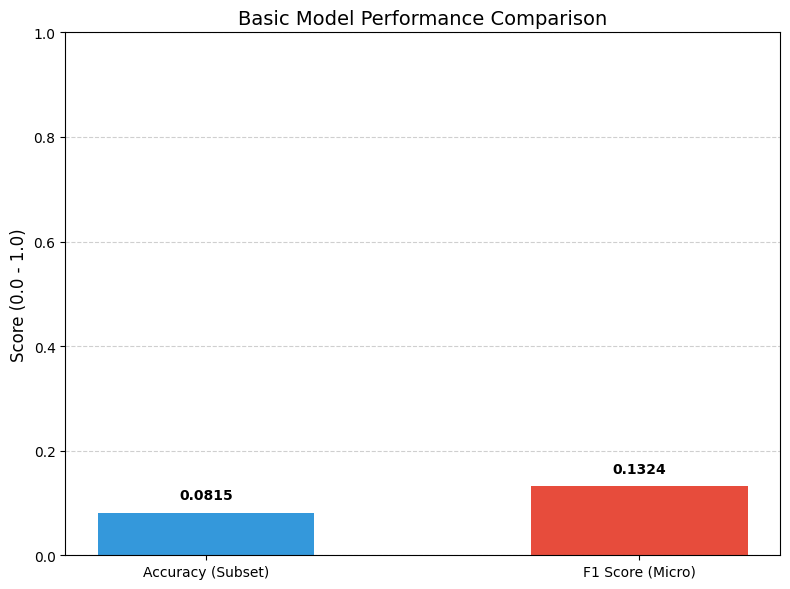

In [ ]:
import matplotlib.pyplot as plt

# 1. Prepare data
metrics = ['Accuracy (Subset)', 'F1 Score (Micro)']
scores = [basic_accuracy, basic_f1]

# 2. Create the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(metrics, scores, color=['#3498db', '#e74c3c'], width=0.5)

# 3. Add labels and formatting
plt.ylim(0, 1.0)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.title('Basic Model Performance Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add the specific values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()